# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Стандартная форма:**

<p style="text-align:left;">
$x = (x_1, x_2, x_3) \in \mathbb{R}^3$<br>
$f(x) = (x_1 - 1)^2 + (x_2 - 2)^2 + (x_3 - 3)^2 \rightarrow \min$<br>
$g(x) = \begin{cases} x_1 + x_2 + x_3 = 1 \\ x_1 - x_3 = 0 \end{cases}$<br>
$h(x) = \varnothing$
</p>

**Класс:** QP, т.к. f - сумма квадратов, а ограничения - равенства  
Выпуклая, т.к. гессиан равен $2I \succ 0$ (положительно определен)  
**Аналитическое решение:**

Из условия $x_1 - x_3 = 0$ следует, что $x_1 = x_3 = t$.

Подставим его в первое уравнение:
$$t + x_2 + t = 1 \Rightarrow x_2 = 1 - 2t$$

Параметризация точки:
$$x = (t, \; 1 - 2t, \; t)$$

Подставляем в целевую функцию, этап раскрытия скобок пропускаю:

$$f(t) = (t-1)^2 + (1-2t-2)^2 + (t-3)^2$$

$$f(t) = 6t^2 - 4t + 11$$

Приравниваем производную к нулю, находим точку экстремума:
$$f'(t) = 12t - 4 = 0 \Rightarrow t = \frac{1}{3}$$

Находим координаты точки:

$$x_1 = x_3 = t = \frac{1}{3}, \quad x_2 = 1 - 2 \cdot \frac{1}{3} = \frac{1}{3}$$

**Ответ:** $\boxed{x = \left(\frac{1}{3}, \frac{1}{3}, \frac{1}{3}\right)}$

**Расстояние** от $(1,2,3)$ до $(\frac{1}{3},\frac{1}{3},\frac{1}{3})$ = $\sqrt{\frac{93}{9}} \approx 3.21$

In [2]:
import numpy as np
from scipy.optimize import minimize

# Целевая функция и ограничения
def f(x):
    return (x[0] - 1)**2 + (x[1] - 2)**2 + (x[2] - 3)**2

def g(x):
    return [
        x[0] + x[1] + x[2] - 1,
        x[0] - x[2]
    ]

# В качестве начального приближения возьму точку на прямой (0; 1; 0)
# Удовлетворяет обоим ограничениям: 1) 0 + 1 + 0 = 1; 2) 0 - 0 = 0
x0 = np.array([0.0, 1.0, 0.0])

# Решение задачи оптимизации
result = minimize(f, x0, constraints={'type': 'eq', 'fun': g}, method='SLSQP')

print("Оптимум:", result.x)
print("f(опт):", result.fun) # Квадрат расстояния
print("Расстояние:", result.fun**0.5) # Расстояние

# Проверка ограничений
print("x1+x2+x3 =", result.x[0] + result.x[1] + result.x[2], "- близко к 1")
print("x1-x3 =", result.x[0] - result.x[2], "- численный ноль")

Оптимум: [0.33333333 0.33333333 0.33333333]
f(опт): 10.333333333333332
Расстояние: 3.214550253664318
x1+x2+x3 = 0.9999999999999998 - близко к 1
x1-x3 = 5.551115123125783e-17 - численный ноль


**(б)**

**Ответ:**

**Стандартная форма:**
<p style="text-align:left;">
$x = (x_1, \dots, x_n) \in \mathbb{R}^n$<br>
$f(x) = \sum_{j=1}^{n} c_j x_j \rightarrow \min$<br>
$g(x) = \varnothing$<br>
$h(x) = \begin{cases} \sum_{j=1}^{n} A_{ij} x_j \geq b_i, \quad i = 1,\dots,m \\ x_j \geq 0, \quad j = 1,\dots,n \end{cases}$
</p>

**Класс:** LP (линейная функция и ограничения), с ограничениями, выпуклая (т.к. функция выпуклая, а ограничения образуют выпуклый многогранник)

**(в)**

**Ответ:**  
**Стандартная форма:**
<p style="text-align:left;">
$x = (x_1, x_2) \in \mathbb{R}^2$<br>
где $2x_1$ — длина, а $2x_2$ — ширина прямоугольника<br>
$f(x) = -4x_1 x_2 \rightarrow \min$<br>
$g(x) = \varnothing$<br>
$h(x) = \begin{cases} x_1^2 + x_2^2 \leq 1 \\ x_1 \geq 0, \; x_2 \geq 0 \end{cases}$
</p>

**Класс:** QCQP, с ограничениями, **не выпуклая** (т.к.гессиан $f$: $\begin{pmatrix} 0 & -2 \\ -2 & 0 \end{pmatrix}$ отрицательно определен).

**Аналитическое решение:**
<p style="text-align:left;">
Экстремум лежит на границе области $x_1^2 + x_2^2 = 1$. Выразим $x_2$ через $x_1$ (учитывая $x_2 \geq 0$):<br>
$x_2 = \sqrt{1 - x_1^2}$<br>
<br>
Подставим в функцию площади (ищем максимум: $S(x) = -f(x) = 4x_1x_2$):<br>
$S(x_1) = 4x_1\sqrt{1 - x_1^2}$<br>
<br>
Найдем производную по $x_1$:<br>
$S'(x_1) = 4\sqrt{1 - x_1^2} + 4x_1 \cdot \frac{-2x_1}{2\sqrt{1 - x_1^2}} = 4\sqrt{1 - x_1^2} - \frac{4x_1^2}{\sqrt{1 - x_1^2}}$<br>
<br>
Приведем к общему знаменателю и приравняем к нулю:<br>
$\frac{4(1 - x_1^2) - 4x_1^2}{\sqrt{1 - x_1^2}} = 0 \implies 4 - 8x_1^2 = 0$<br>
$x_1^2 = \frac{1}{2} \implies x_1 = \frac{1}{\sqrt{2}}$<br>
<br>
Находим вторую сторону прямоугольника:<br>
$x_2 = \sqrt{1 - (\frac{1}{\sqrt{2}})^2} = \frac{1}{\sqrt{2}}$
</p>

Ответ: квадрат со стороной $\sqrt{2}$.

**(г)**

**Ответ:**
**Стандартная форма:**
<p style="text-align:left;">
$x = (x_1, x_2, x_3) \in \mathbb{R}^3$<br>
$f(x) = \sum_{i=1}^{N} \left( y_i - x_1 \sin(x_2 t_i + x_3) \right)^2 \rightarrow \min$<br>
где $x_1$ — амплитуда, $x_2$ — частота, а $x_3$ — фазовый сдвиг синусоиды<br>
$g(x) = \varnothing$<br>
$h(x) = \varnothing$
</p>

**Класс:** NLP, без ограничений, **не выпуклая** (из-за наличия $\sin$ с множеством локальных минимумов).


**(д, бонус)**

**Ответ:**  
**Стандартная форма:**
<p style="text-align:left;">
Заменяем негладкую операцию максимума $\max_i |a_i^\top x - b_i|$ дополнительной переменной $t \in \mathbb{R}$, которая будет служить максимумом для всех модулей ошибок:<br>
$\tilde{x} = (x_1, \dots, x_n, t) \in \mathbb{R}^{n+1}$<br>
$f(\tilde{x}) = t \rightarrow \min$<br>
$g(\tilde{x}) = \varnothing$<br>
<br>
Избавимся от операции $\max$, раскрываем модуль:<br>
$h(\tilde{x}) = \begin{cases} a_i^\top x - b_i \leq t, \quad i = 1, \dots, N \\ b_i - a_i^\top x \leq t, \quad i = 1, \dots, N \end{cases}$<br>
<br>
В стандартной форме (переменные слева, константы справа):<br>
$h(\tilde{x}) = \begin{cases} a_i^\top x - t \leq b_i, \quad i = 1, \dots, N \\ -a_i^\top x - t \leq -b_i, \quad i = 1, \dots, N \end{cases}$
</p>

**Класс:** Получили задачу LP, целевая функция и ограничения линейные. C ограничениями, выпуклая (т.к. и целевая функция, и область являются выпуклыми).


## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

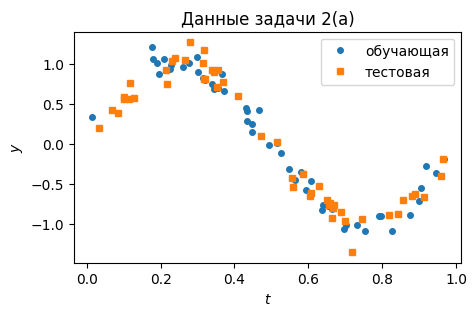

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

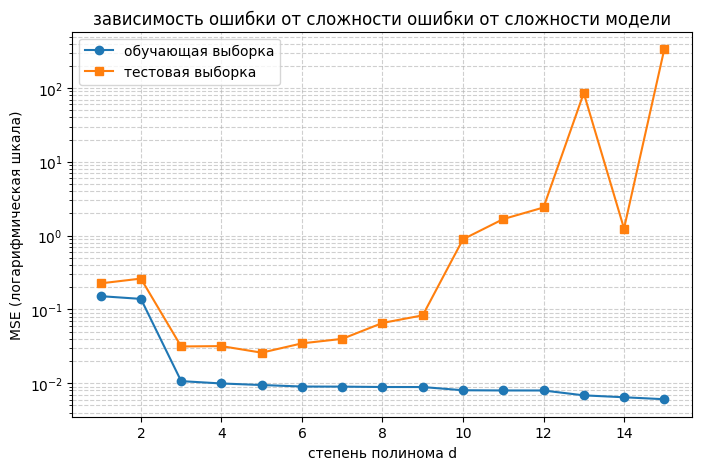

Степень | MSE_train | MSE_test
      1 | 0.151469 | 0.225799
      2 | 0.139123 | 0.262077
      3 | 0.010690 | 0.031528
      4 | 0.009933 | 0.031880
      5 | 0.009464 | 0.025973
      6 | 0.009030 | 0.034745
      7 | 0.009000 | 0.039952
      8 | 0.008896 | 0.065674
      9 | 0.008887 | 0.083233
     10 | 0.008038 | 0.894223
     11 | 0.007988 | 1.678856
     12 | 0.007981 | 2.409830
     13 | 0.006857 | 85.707173
     14 | 0.006461 | 1.250068
     15 | 0.006077 | 336.493927


In [4]:
# степени и ошибки
degrees = np.arange(1, 16)
train_errors = []
test_errors = []

for d in degrees: # идем по всем степеням
    A_train = np.vander(t_train, d + 1, increasing=True)
    A_test = np.vander(t_test, d + 1, increasing=True)

    # решаем мнк
    x, residuals, rank, s = np.linalg.lstsq(A_train, y_train, rcond=None)

    # Предсказания
    y_train_pred = A_train @ x #обучающая выборка
    y_test_pred = A_test @ x # тестовая выборка

    # MSE
    mse_train = np.mean((y_train - y_train_pred) ** 2)
    mse_test = np.mean((y_test - y_test_pred) ** 2)

    train_errors.append(mse_train)
    test_errors.append(mse_test)

# график зависимости MSE от степени полинома
# шкала логарифмическая сугубо для понимания порядка ошибки
# не вдаёмся в подробности мелких расхождений
plt.figure(figsize=(8, 5))
plt.semilogy(degrees, train_errors, 'o-', label='обучающая выборка')
plt.semilogy(degrees, test_errors, 's-', label='тестовая выборка')
plt.xlabel('степень полинома d')
plt.ylabel('MSE (логарифмическая шкала)')
plt.title('зависимость ошибки от сложности ошибки от сложности модели')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

# выводим значения
print("Степень | MSE_train | MSE_test")
for i, d in enumerate(degrees):
    print(f"{d:7d} | {train_errors[i]:.6f} | {test_errors[i]:.6f}")

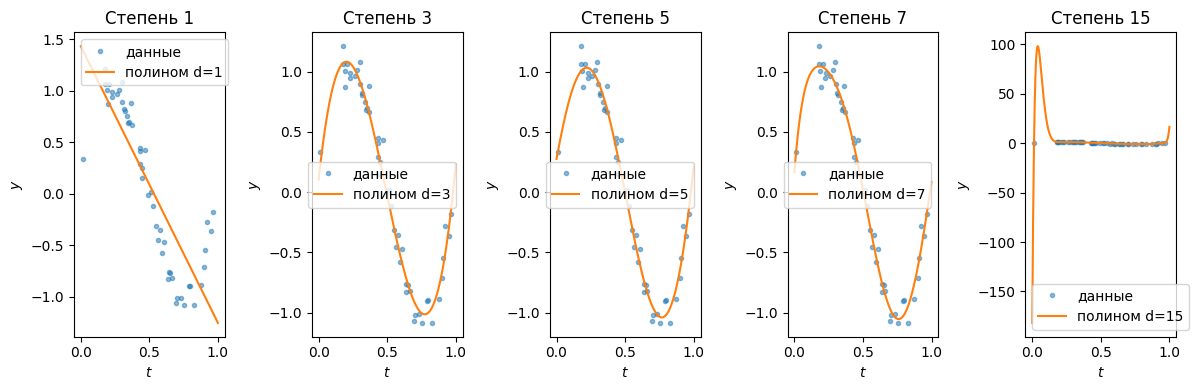

In [5]:
# визуализация полиномов
plt.figure(figsize=(12, 4))

for idx, d in enumerate([1, 3, 5, 7, 15]):
    plt.subplot(1, 5, idx + 1)

    A_train = np.vander(t_train, d + 1, increasing=True)
    x, _, _, _ = np.linalg.lstsq(A_train, y_train, rcond=None)

    # сетка
    t_smooth = np.linspace(0, 1, 500)
    A_smooth = np.vander(t_smooth, d + 1, increasing=True)
    y_smooth = A_smooth @ x

    plt.plot(t_train, y_train, 'o', ms=3, alpha=0.5, label='данные')
    plt.plot(t_smooth, y_smooth, '-', label=f'полином d={d}')
    plt.legend()
    plt.xlabel('$t$')
    plt.ylabel('$y$')
    plt.title(f'Степень {d}')

plt.tight_layout()
plt.show()

In [6]:
# глянем коэффициенты полиномов
d = 15
A_train = np.vander(t_train, d + 1, increasing=True)
x, _, _, _ = np.linalg.lstsq(A_train, y_train, rcond=None)

print("Коэффициенты")
for i, coef in enumerate(x):
    print(f"x_{i} = {coef:.6e}")

Коэффициенты
x_0 = -1.817294e+02
x_1 = 2.004077e+04
x_2 = -5.421532e+05
x_3 = 7.423312e+06
x_4 = -6.309055e+07
x_5 = 3.653614e+08
x_6 = -1.515994e+09
x_7 = 4.636520e+09
x_8 = -1.060716e+10
x_9 = 1.823391e+10
x_10 = -2.343818e+10
x_11 = 2.218163e+10
x_12 = -1.499295e+10
x_13 = 6.845140e+09
x_14 = -1.890521e+09
x_15 = 2.384339e+08


**Ответ:**
<p style="text-align:left;">
С ростом степени полинома модель становится сложнее и подстраивается под каждую точку обучающей выборки, вследствие чего ошибка монотонно стремится к нулю.<br>
На тесте ошибка сначала падает, но при больших степенях резко растет из-за переобучения. Полином начинает описывать случайный шум.<br>
Это подтверждают коэффициенты модели, которые выросли до $10$-го порядка, из-за чего на графике исходные данные визуально превратились в прямую $y = \text{const}$.
</p>


**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [7]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [8]:
from scipy.optimize import linprog

# со знаком минус
A_ub = -A
b_ub = -b

# решаем исходную задачу
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, None), method='highs')

##исходные данные
print("x =", res.x)
print("стоимость =", res.fun)
print()

# смотрим какие ограничения активны (невязка = 0)
# считаем Ax - b и смотрим что близко к нулю
print("Проверка ограничений Ax >= b:")
for i in range(3):
    nev = A[i] @ res.x - b[i]   # невязка
    if abs(nev) < 1e-9:
        print(f"  огр {i+1}: активно (невязка = {nev:.1e})")
    else:
        print(f"  огр {i+1}: не активно (невязка = {nev:.1e})")

# то же для x >= 0
print("\nПроверка x >= 0:")
for j in range(4):
    if abs(res.x[j]) < 1e-9:
        print(f"  x_{j+1} = {res.x[j]:.3f}: активно")
    else:
        print(f"  x_{j+1} = {res.x[j]:.3f}: не активно")

# теперь меняем b1 на +1 и решаем заново
b_new = b.copy()        # копия чтоб не портить исходный массив
b_new[0] += 1           # увеличили первый элемент на 1

res2 = linprog(c, A_ub=-A, b_ub=-b_new, bounds=(0, None), method='highs')

print("\nНовое b1:")
print("x =", res2.x)
print("стоимость =", res2.fun)
print()

# опять проверяем что активно
print("Проверка ограничений Ax >= b_new:")
for i in range(3):
    nev = A[i] @ res2.x - b_new[i]
    if abs(nev) < 1e-9:
        print(f"  огр {i+1}: активно (невязка = {nev:.1e})")
    else:
        print(f"  огр {i+1}: не активно (невязка = {nev:.1e})")

print("\nПроверка x >= 0:")
for j in range(4):
    if abs(res2.x[j]) < 1e-9:
        print(f"  x_{j+1} = {res2.x[j]:.3f}: активно")
    else:
        print(f"  x_{j+1} = {res2.x[j]:.3f}: не активно")

# сравниваем результаты
print("Сравниваем:")
print(f"стоимость: {res.fun} -> {res2.fun}, разница = {(res2.fun - res.fun):.3f}")
print(f"x: {res.x} -> {res2.x}")

x = [ 2.  4. -0.  0.]
стоимость = 16.0

Проверка ограничений Ax >= b:
  огр 1: активно (невязка = 0.0e+00)
  огр 2: активно (невязка = 0.0e+00)
  огр 3: активно (невязка = 0.0e+00)

Проверка x >= 0:
  x_1 = 2.000: не активно
  x_2 = 4.000: не активно
  x_3 = -0.000: активно
  x_4 = 0.000: активно

Новое b1:
x = [1.88888889 3.55555556 0.         0.66666667]
стоимость = 17.11111111111111

Проверка ограничений Ax >= b_new:
  огр 1: активно (невязка = 0.0e+00)
  огр 2: активно (невязка = 0.0e+00)
  огр 3: активно (невязка = 0.0e+00)

Проверка x >= 0:
  x_1 = 1.889: не активно
  x_2 = 3.556: не активно
  x_3 = 0.000: активно
  x_4 = 0.667: не активно
\Сравниваем:
стоимость: 16.0 -> 17.11111111111111, разница = 1.111
x: [ 2.  4. -0.  0.] -> [1.88888889 3.55555556 0.         0.66666667]


**Ответ:**  

Сравнение результатов при изменении $b_1 \rightarrow b_1 + 1$:
<p style="text-align:left;">
1. Финальная стоимость увеличилась с $16.0$ до $\approx 17.111$ <br>
2. Потребление компонентов $x_1$ и $x_2$ снизилось ($2 \rightarrow 1.889$ и $4 \rightarrow 3.556$ соответственно), использование $x_3$ осталось нулевым, а переменная $x_4$ стала положительной ($0 \rightarrow 0.667$).<br>
3. Основные ограничения ($Ax \geq b$) остались активными,
ограничение $x_4$ стало пассивным.

Все изменения закономерны: при увеличении потребностей растут и затраты. Продукт $x_4$ является самым богатым по содержанию витамина $b_1$, поэтому докупили именно его.
</p>
